In [ ]:
# @title
import os
import json
import datetime
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
try:
  drive.mount('/content/drive')
  MOUNT_TARGET = "GOOGLE"
except:
  print("Warning: using local files for data instead of Google Drive !!!!!!!!!!!!!!! ")
  MOUNT_TARGET = "LOCAL"

In [ ]:
# @title
# =========================
# COLUMN NORMALIZATION STEP
# =========================

TIME_COL = "time_s"
SPEED_COL = "speed_km_h"
STEER_COL = "steering_angle_rad"

def normalize_columns(df):
    rename_dict = {
        "timestamp": TIME_COL,
        "cmd_speed": SPEED_COL,
        "cmd_angle": STEER_COL,
    }

    # Handle lidar columns: lidar[-180] → lidar_-180
    for angle in range(-180, 181):
        old_name = f"lidar[{angle}]"
        if angle >= 0 and angle < 180:
            new_name = f"lidar_{angle-180}"
        else:
            new_name = f"lidar_{angle+180}"
        if old_name in df.columns:
            rename_dict[old_name] = new_name

    df = df.rename(columns=rename_dict)

    return df

In [ ]:
# @title
if MOUNT_TARGET == "GOOGLE":
  DATA_FOLDER = "/content/drive/MyDrive/Lidar_data"
else:
  DATA_FOLDER = "/content/Lidar_data"
FILE_PATTERN = "*.csv"

ANGLES_DEG = [-30, 0, 30]

# --- CSV column names ---
TIME_COL = "time_s"
SPEED_COL = "speed_km_h"
STEER_COL = "steering_angle_rad"

# --- nominal ego inputs ---
V_NOM = 3.0
DELTA_NOM = 0.0

# --- nominal LiDAR distance for centering ---
D_NOM = 2.0   # meters

# --- ARX orders ---
NA = 4 # for previous LIDAR
NB = 4 # for previous commands

# --- simulator timestep ---
TS = 0.032

# --- interval duration ---
INTERVAL_DURATION = 1.6

ratio = INTERVAL_DURATION / TS
if abs(ratio - round(ratio)) > 1e-12:
    raise ValueError("INTERVAL_DURATION must be an integer multiple of TS")
INTERVAL_LEN = int(round(ratio))

# --- reference obstacle speed used only for ramp interpretation ---
V_OBS_REF = 3.0

# --- optional LiDAR clipping / cleaning ---
USE_LIDAR_CLIP = False
LIDAR_MIN = 0.0
LIDAR_MAX = None   # or put your circuit max distance if you want

# --- file split ---
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# --- plotting ---
N_PLOTS_PER_SPLIT = 3

In [ ]:
# @title
# ============================================================
# GRID SEARCH PARAMETERS
# ============================================================

D_NOM_LIST = [2.0]
INTERVAL_DURATION_LIST = [6.624, 6.656, 6.688, 6.72, 6.752]

REG_ALPHA = 1e-3   # if you use ridge regularization

In [ ]:
# @title
def angle_to_lidar_col(angle_deg):
    """
    Adapt this function if your CSV naming differs.
    Example:
      angle -30 -> lidar_150
      angle   0 -> lidar_180
      angle  30 -> lidar_210
    """
    return f"lidar_{angle_deg}"


def load_csv_files(folder, pattern="*.csv"):
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder} with pattern {pattern}")
    return files


"""
def split_files(files, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    n = len(files)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    return train_files, val_files, test_files
"""

def compute_intrusion(distance_series, d_nom, use_clip=True, intr_min=0.0, intr_max=None):
    intr = d_nom - distance_series.astype(float)
    if use_clip:
        max_val = intr_max if intr_max is not None else np.inf
        intr = np.clip(intr, intr_min, max_val)
    return intr

In [ ]:
# @title
def interpolate_nan_columns(df):
    df = df.copy()

    # 1) interpolate main numeric columns over time
    for col in [TIME_COL, SPEED_COL, STEER_COL]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].interpolate(method="linear", limit_direction="both")

    # 2) interpolate lidar columns over time, column by column
    lidar_cols = []
    for angle in range(-180, 181):
        col = f"lidar_{angle}"
        if col in df.columns:
            lidar_cols.append(col)

    for col in lidar_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].interpolate(method="linear", limit_direction="both")

    return df

In [ ]:
# @title
def split_dataframe(df, train_ratio=0.7, val_ratio=0.15, na=6, nb=6):
    """
    Split one dataframe into contiguous train / val / test parts.
    A buffer is inserted between parts to avoid ARX leakage across boundaries.
    """
    n = len(df)
    buffer = max(na, nb) + 1

    train_end = int(train_ratio * n)
    val_end = int((train_ratio + val_ratio) * n)

    df_train = df.iloc[:train_end].reset_index(drop=True)
    df_val   = df.iloc[train_end + buffer:val_end].reset_index(drop=True)
    df_test  = df.iloc[val_end + buffer:].reset_index(drop=True)

    return df_train, df_val, df_test

In [ ]:
# @title
# =========================
# DATA PREPARATION STAGE
# =========================
files = load_csv_files(DATA_FOLDER, FILE_PATTERN)

train_dfs = []
val_dfs = []
test_dfs = []

for file_path in files:
    df = pd.read_csv(file_path)
    df = normalize_columns(df)
    df = interpolate_nan_columns(df)

    df_train, df_val, df_test = split_dataframe(df, na=6, nb=6) ############# why not use the previously defined NA and NB variables ?

    train_dfs.append(df_train)
    val_dfs.append(df_val)
    test_dfs.append(df_test)

"""
# Merge everything
df_train = pd.concat(train_dfs, ignore_index=True)
df_val   = pd.concat(val_dfs, ignore_index=True)
df_test  = pd.concat(test_dfs, ignore_index=True)
"""

'\n# Merge everything\ndf_train = pd.concat(train_dfs, ignore_index=True)\ndf_val   = pd.concat(val_dfs, ignore_index=True)\ndf_test  = pd.concat(test_dfs, ignore_index=True)\n'

In [ ]:
# @title
def preprocess_dataframe(df,
                         angles_deg,
                         speed_col,
                         steer_col,
                         v_nom,
                         delta_nom,
                         d_nom,
                         use_lidar_clip=False,
                         lidar_min=0.0,
                         lidar_max=None):
    """
    Builds:
      - delta_v = speed - V_NOM
      - delta_delta = steering - DELTA_NOM
      - delta_y_angle = lidar_angle - D_NOM

    So the model works on LiDAR variations around the nominal distance d_nom.
    """
    out = df.copy()

    required_cols = [speed_col, steer_col]
    for c in required_cols:
        if c not in out.columns:
            raise KeyError(f"Missing required column: {c}")

    out["delta_v"] = out[speed_col].astype(float) - v_nom
    out["delta_delta"] = out[steer_col].astype(float) - delta_nom

    for ang in angles_deg:
        lidar_col = angle_to_lidar_col(ang)
        if lidar_col not in out.columns:
            raise KeyError(f"Missing LiDAR column: {lidar_col}")

        y = out[lidar_col].astype(float).copy()

        # Treat zeros as invalid only if that is true in your data.
        # If 0 is physically meaningful in your files, remove these 2 lines.
        y = y.replace(0.0, np.nan)
        y = y.interpolate(limit_direction="both")

        if use_lidar_clip:
            y = np.clip(
                y,
                lidar_min,
                np.inf if lidar_max is None else lidar_max
            )

        out[lidar_col] = y
        out[f"delta_y_{ang}"] = y - d_nom

    return out


def assign_interval_ids_and_local_ramps(df, interval_len, ts):
    """
    Splits the whole file into intervals of length interval_len samples.
    For each sample:
      - interval_id identifies its interval
      - interval_local_idx is the local sample index inside that interval
      - interval_local_time = interval_local_idx * ts

    This yields the desired ramp:
      0, Ts, 2Ts, 3Ts, ...
    inside each interval, and zero outside when used as a one-hot interval basis.
    """
    out = df.copy().reset_index(drop=True)
    n = len(out)

    interval_ids = np.arange(n) // interval_len
    local_idx = np.arange(n) % interval_len

    out["interval_id"] = interval_ids
    out["interval_local_idx"] = local_idx.astype(float)
    out["interval_local_time"] = local_idx.astype(float) * ts

    return out

In [ ]:
# @title
def build_file_dataset_for_angle(df, angle, na, nb, include_ramps=True):
    """
    Builds one regression dataset for one angle over one file.

    Model:
      delta_y_i(k+1)
        = sum_p a_p delta_y_i(k-p)
        + sum_q b_v_q delta_v(k-q)
        + sum_q b_d_q delta_delta(k-q)
        + sum_j c_j r_j(k)

    where:
      r_j(k) = k_local * Ts inside interval j
               0            outside interval j
    """
    y = df[f"delta_y_{angle}"].to_numpy(dtype=float)
    d_raw = df[angle_to_lidar_col(angle)].to_numpy(dtype=float)

    dv = df["delta_v"].to_numpy(dtype=float)
    dd = df["delta_delta"].to_numpy(dtype=float)

    interval_ids = df["interval_id"].to_numpy(dtype=int)
    local_ramp = df["interval_local_time"].to_numpy(dtype=float)

    n = len(df)
    if n == 0:
        return None

    n_intervals = int(interval_ids.max()) + 1
    max_lag = max(na, nb)

    X_rows = []
    Y_rows = []
    D_rows = []
    meta_rows = []

    for k in range(max_lag - 1, n - 1):
        row = []

        # past output deviations
        for p in range(na):
            row.append(y[k - p])

        # past speed deviations
        for q in range(nb):
            row.append(dv[k - q])

        # past steering deviations
        for q in range(nb):
            row.append(dd[k - q])

        # interval ramp basis
        if include_ramps:
            ramps = np.zeros(n_intervals, dtype=float)
            j = interval_ids[k]
            ramps[j] = local_ramp[k]
            row.extend(ramps.tolist())

        X_rows.append(row)
        Y_rows.append(y[k + 1])       # true next centered LiDAR deviation
        D_rows.append(d_raw[k + 1])   # true next raw LiDAR distance

        meta_rows.append({
            "k": k,
            "interval_id": int(interval_ids[k]),
            "local_time": float(local_ramp[k])
        })

    if len(X_rows) == 0:
        return None

    X = np.asarray(X_rows, dtype=float)
    Y = np.asarray(Y_rows, dtype=float)
    D = np.asarray(D_rows, dtype=float)
    meta = pd.DataFrame(meta_rows)

    mask = np.isfinite(X).all(axis=1) & np.isfinite(Y) & np.isfinite(D)
    X = X[mask]
    Y = Y[mask]
    D = D[mask]
    meta = meta.loc[mask].reset_index(drop=True)

    if len(X) == 0:
        return None

    return {
        "X": X,
        "Y_delta": Y,
        "D_true": D,
        "meta": meta,
        "n_intervals": n_intervals
    }


def build_split_dataset(dfs,
                        angles_deg,
                        na,
                        nb,
                        speed_col,
                        steer_col,
                        v_nom,
                        delta_nom,
                        d_nom,
                        interval_len,
                        ts,
                        use_lidar_clip=False,
                        lidar_min=0.0,
                        lidar_max=None,
                        include_ramps=True):
    """
    Builds one stacked dataset per angle for a list of files.
    """
    split_data = {ang: [] for ang in angles_deg}


    for df_raw in dfs:

        df = preprocess_dataframe(
            df_raw,
            angles_deg=angles_deg,
            speed_col=speed_col,
            steer_col=steer_col,
            v_nom=v_nom,
            delta_nom=delta_nom,
            d_nom=d_nom,
            use_lidar_clip=use_lidar_clip,
            lidar_min=lidar_min,
            lidar_max=lidar_max
        )

        n_full = (len(df) // interval_len) * interval_len
        df = df.iloc[:n_full].reset_index(drop=True)
        if len(df) == 0:
            continue

        df = assign_interval_ids_and_local_ramps(
            df=df,
            interval_len=interval_len,
            ts=ts
        )

        for ang in angles_deg:
            out = build_file_dataset_for_angle(
                df=df,
                angle=ang,
                na=na,
                nb=nb,
                include_ramps=include_ramps
            )

            if out is None:
                continue

            split_data[ang].append({
                "file": file_path,
                "X": out["X"],
                "Y_delta": out["Y_delta"],
                "D_true": out["D_true"],
                "meta": out["meta"],
                "n_intervals": out["n_intervals"]
            })

    return split_data

In [ ]:
# @title
def solve_least_squares(X, Y, alpha=1e-3):
    if X is None or Y is None or len(X) == 0:
        return None
    n = X.shape[1]
    return np.linalg.solve(X.T @ X + alpha * np.eye(n), X.T @ Y)


def predict_linear(X, theta):
    return X @ theta


def fit_models_per_angle(train_data, angles_deg, na, nb, alpha=1e-3):
    """
    Fits one model per angle using the centered LiDAR variation target:
        Y_delta = y - D_NOM
    """
    models = {}
    dyn_size = na + nb + nb

    for ang in angles_deg:
        chunks = train_data[ang]
        if len(chunks) == 0:
            continue

        X_dyn_list = []
        X_ramp_list = []
        Y_list = []

        max_ramps = max(c["X"].shape[1] - dyn_size for c in chunks)

        for c in chunks:
            X = c["X"]
            Y = c["Y_delta"]

            X_dyn = X[:, :dyn_size]
            X_ramp = X[:, dyn_size:]

            cur_ramps = X_ramp.shape[1]
            if cur_ramps < max_ramps:
                pad = np.zeros((X_ramp.shape[0], max_ramps - cur_ramps))
                X_ramp = np.hstack([X_ramp, pad])

            X_dyn_list.append(X_dyn)
            X_ramp_list.append(X_ramp)
            Y_list.append(Y)

        X_dyn_all = np.vstack(X_dyn_list)
        X_ramp_all = np.vstack(X_ramp_list)
        Y_all = np.concatenate(Y_list)

        X_all = np.hstack([X_dyn_all, X_ramp_all]) if max_ramps > 0 else X_dyn_all

        n_features = X_all.shape[1]
        reg = np.zeros(n_features)
        reg[:dyn_size] = alpha

        A = X_all.T @ X_all + np.diag(reg)
        b = X_all.T @ Y_all
        theta = np.linalg.solve(A, b)

        a_coeffs = theta[:na]
        b_v = theta[na:na + nb]
        b_delta = theta[na + nb:na + 2 * nb]
        ramp_coeffs = theta[dyn_size:] if n_features > dyn_size else np.array([])

        models[ang] = {
            "theta": theta,
            "a_coeffs": a_coeffs,
            "b_v": b_v,
            "b_delta": b_delta,
            "ramp_coeffs": ramp_coeffs,
            "n_train_samples": len(Y_all),   # <- added
            "n_ramps": len(ramp_coeffs)      # <- useful too
        }

    return models

In [ ]:
# @title
def evaluate_split(split_data,
                   models,
                   angles_deg,
                   na,
                   nb,
                   d_nom):
    """
    Evaluates each split.

    The model predicts centered LiDAR variations:
      delta_y = y - d_nom

    Then the raw LiDAR distance is reconstructed as:
      y = d_nom + delta_y
    """
    predictions = []

    for ang in angles_deg:
        model = models.get(ang, None)
        if model is None:
            continue

        theta = model["theta"]
        trained_ramp_count = len(model["ramp_coeffs"])

        for item in split_data[ang]:
            X = item["X"].copy()
            Y_true = item["Y_delta"]
            D_true = item["D_true"]
            meta = item["meta"]
            file_path = item["file"]

            dyn_size = na + nb + nb
            X_dyn = X[:, :dyn_size]
            X_ramp = X[:, dyn_size:]

            current_ramp_count = X_ramp.shape[1]

            if current_ramp_count < trained_ramp_count:
                pad = np.zeros((X_ramp.shape[0], trained_ramp_count - current_ramp_count))
                X_ramp = np.hstack([X_ramp, pad])
            elif current_ramp_count > trained_ramp_count:
                X_ramp = X_ramp[:, :trained_ramp_count]

            X_eval = np.hstack([X_dyn, X_ramp])
            Y_pred = predict_linear(X_eval, theta)

            D_pred = d_nom + Y_pred

            if trained_ramp_count > 0:
                ramp_contrib = X_ramp @ model["ramp_coeffs"]
            else:
                ramp_contrib = np.zeros_like(Y_pred)

            mse = np.mean((Y_true - Y_pred) ** 2)
            rmse = np.sqrt(mse)

            denom = np.sum((Y_true - np.mean(Y_true)) ** 2)
            r2 = np.nan if denom < 1e-12 else 1 - np.sum((Y_true - Y_pred) ** 2) / denom

            predictions.append({
                "file": file_path,
                "angle": ang,
                "Y_delta_true": Y_true,
                "Y_delta_pred": Y_pred,
                "D_true": D_true,
                "D_pred": D_pred,
                "ramp_contrib": ramp_contrib,
                "meta": meta,
                "rmse": rmse,
                "r2": r2
            })

    return predictions


def predictions_to_dataframe(predictions):
    rows = []
    for item in predictions:
        rows.append({
            "file": os.path.basename(item["file"]),
            "angle": item["angle"],
            "rmse": item["rmse"],
            "r2": item["r2"],
            "n_samples": len(item["Y_delta_true"])
        })
    return pd.DataFrame(rows)

In [ ]:
# @title
def summarize_model_coefficients(models, v_obs_ref):
    global_rows = []
    ramp_rows = []

    for ang, m in models.items():
        row = {
            "angle": ang,
            "n_train_samples": m.get("n_train_samples", np.nan),
            "a_coeffs": m["a_coeffs"],
            "b_v": m["b_v"],
            "b_delta": m["b_delta"],
            "n_ramps": len(m.get("ramp_coeffs", []))
        }
        global_rows.append(row)

        ramp_coeffs = m.get("ramp_coeffs", np.array([]))
        for j, rc in enumerate(ramp_coeffs):
            ramp_rows.append({
                "angle": ang,
                "interval_id": j,
                "ramp_coeff": rc,
                "gamma_interval": rc / v_obs_ref if abs(v_obs_ref) > 1e-12 else np.nan
            })

    global_coeff_df = pd.DataFrame(global_rows)
    ramp_coeff_df = pd.DataFrame(ramp_rows)

    return global_coeff_df, ramp_coeff_df

In [ ]:
# @title
def plot_some_delta_predictions(predictions, max_plots=3, title_prefix=""):
    n = min(max_plots, len(predictions))
    for i in range(n):
        item = predictions[i]

        plt.figure(figsize=(10, 4))
        plt.plot(item["Y_delta_true"], label="true delta LiDAR")
        plt.plot(item["Y_delta_pred"], label="predicted delta LiDAR")
        plt.plot(item["ramp_contrib"], label="ramp contribution")
        plt.axhline(0.0, linestyle="--", linewidth=1)
        plt.title(f"{title_prefix} | {os.path.basename(item['file'])} | angle={item['angle']} deg")
        plt.xlabel("sample")
        plt.ylabel("delta LiDAR = y - D_NOM")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_some_lidar_predictions(predictions, d_nom, max_plots=3, title_prefix=""):
    n = min(max_plots, len(predictions))
    for i in range(n):
        item = predictions[i]

        plt.figure(figsize=(10, 4))
        plt.plot(item["D_true"], label="true next LiDAR distance")
        plt.plot(item["D_pred"], label="predicted next LiDAR distance")
        plt.axhline(d_nom, linestyle="--", linewidth=1, label="D_NOM")
        plt.title(f"{title_prefix} | {os.path.basename(item['file'])} | angle={item['angle']} deg")
        plt.xlabel("sample")
        plt.ylabel("LiDAR distance")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_ramp_coefficients(ramp_df):
    if len(ramp_df) == 0:
        return

    for ang in sorted(ramp_df["angle"].unique()):
        tmp = ramp_df[ramp_df["angle"] == ang].sort_values("interval_id")

        plt.figure(figsize=(10, 4))
        plt.plot(tmp["interval_id"], tmp["ramp_coeff"], marker="o")
        plt.title(f"Estimated ramp coefficients for angle {ang} deg")
        plt.xlabel("interval_id")
        plt.ylabel("ramp coefficient")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(tmp["interval_id"], tmp["gamma_interval"], marker="o")
        plt.title(f"Estimated gamma = ramp_coeff / V_OBS_REF for angle {ang} deg")
        plt.xlabel("interval_id")
        plt.ylabel("gamma_interval")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [ ]:
# @title
def run_one_experiment(files,
                       d_nom,
                       interval_duration,
                       ts,
                       angles_deg,
                       na,
                       nb,
                       speed_col,
                       steer_col,
                       v_nom,
                       delta_nom,
                       train_ratio,
                       val_ratio,
                       test_ratio,
                       v_obs_ref,
                       alpha=1e-3,
                       use_lidar_clip=False,
                       lidar_min=0.0,
                       lidar_max=None):
    """
    Runs the full pipeline for one (D_NOM, INTERVAL_DURATION) pair.
    The model predicts centered LiDAR variations around d_nom.
    """
    ratio = interval_duration / ts
    if abs(ratio - round(ratio)) > 1e-12:
        raise ValueError(
            f"INTERVAL_DURATION={interval_duration} is not an integer multiple of TS={ts}"
        )
    interval_len = int(round(ratio))

    """
    train_files, val_files, test_files = split_files(
        files,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        test_ratio=test_ratio
    )
    """

    train_data = build_split_dataset(
        dfs=train_dfs,
        angles_deg=angles_deg,
        na=na,
        nb=nb,
        speed_col=speed_col,
        steer_col=steer_col,
        v_nom=v_nom,
        delta_nom=delta_nom,
        d_nom=d_nom,
        interval_len=interval_len,
        ts=ts,
        use_lidar_clip=use_lidar_clip,
        lidar_min=lidar_min,
        lidar_max=lidar_max,
        include_ramps=True
    )

    val_data = build_split_dataset(
        dfs=val_dfs,
        angles_deg=angles_deg,
        na=na,
        nb=nb,
        speed_col=speed_col,
        steer_col=steer_col,
        v_nom=v_nom,
        delta_nom=delta_nom,
        d_nom=d_nom,
        interval_len=interval_len,
        ts=ts,
        use_lidar_clip=use_lidar_clip,
        lidar_min=lidar_min,
        lidar_max=lidar_max,
        include_ramps=True
    )

    test_data = build_split_dataset(
        dfs=test_dfs,
        angles_deg=angles_deg,
        na=na,
        nb=nb,
        speed_col=speed_col,
        steer_col=steer_col,
        v_nom=v_nom,
        delta_nom=delta_nom,
        d_nom=d_nom,
        interval_len=interval_len,
        ts=ts,
        use_lidar_clip=use_lidar_clip,
        lidar_min=lidar_min,
        lidar_max=lidar_max,
        include_ramps=True
    )

    models = fit_models_per_angle(
        train_data=train_data,
        angles_deg=angles_deg,
        na=na,
        nb=nb,
        alpha=alpha
    )

    global_coeff_df, ramp_coeff_df = summarize_model_coefficients(
        models=models,
        v_obs_ref=v_obs_ref
    )

    train_preds = evaluate_split(
        split_data=train_data,
        models=models,
        angles_deg=angles_deg,
        na=na,
        nb=nb,
        d_nom=d_nom
    )

    val_preds = evaluate_split(
        split_data=val_data,
        models=models,
        angles_deg=angles_deg,
        na=na,
        nb=nb,
        d_nom=d_nom
    )

    test_preds = evaluate_split(
        split_data=test_data,
        models=models,
        angles_deg=angles_deg,
        na=na,
        nb=nb,
        d_nom=d_nom
    )

    train_metrics = predictions_to_dataframe(train_preds)
    val_metrics = predictions_to_dataframe(val_preds)
    test_metrics = predictions_to_dataframe(test_preds)

    result = {
        "D_NOM": d_nom,
        "INTERVAL_DURATION": interval_duration,
        "INTERVAL_LEN": interval_len,
        "alpha": alpha,
        "train_rmse_mean": train_metrics["rmse"].mean() if len(train_metrics) else np.nan,
        "val_rmse_mean": val_metrics["rmse"].mean() if len(val_metrics) else np.nan,
        "test_rmse_mean": test_metrics["rmse"].mean() if len(test_metrics) else np.nan,
        "train_r2_mean": train_metrics["r2"].mean() if len(train_metrics) else np.nan,
        "val_r2_mean": val_metrics["r2"].mean() if len(val_metrics) else np.nan,
        "test_r2_mean": test_metrics["r2"].mean() if len(test_metrics) else np.nan,
        "gamma_std": ramp_coeff_df["gamma_interval"].std() if len(ramp_coeff_df) else np.nan,
        "gamma_abs_mean": np.mean(np.abs(ramp_coeff_df["gamma_interval"])) if len(ramp_coeff_df) else np.nan,
        "gamma_mean": ramp_coeff_df["gamma_interval"].mean() if len(ramp_coeff_df) else np.nan,
        "n_ramp_coeffs": len(ramp_coeff_df)
    }

    return {
        "summary": result,
        "models": models,
        "global_coeff_df": global_coeff_df,
        "ramp_coeff_df": ramp_coeff_df,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "train_preds": train_preds,
        "val_preds": val_preds,
        "test_preds": test_preds
    }

In [ ]:
# @title
# ============================================================
# GRID SEARCH MAIN
# ============================================================

all_runs = []
all_results = []

for d_nom in D_NOM_LIST:
    for interval_duration in INTERVAL_DURATION_LIST:
        print(f"Running experiment: D_NOM={d_nom}, INTERVAL_DURATION={interval_duration}")

        run = run_one_experiment(
            files=files,
            d_nom=d_nom,
            interval_duration=interval_duration,
            ts=TS,
            angles_deg=ANGLES_DEG,
            na=NA,
            nb=NB,
            speed_col=SPEED_COL,
            steer_col=STEER_COL,
            v_nom=V_NOM,
            delta_nom=DELTA_NOM,
            train_ratio=TRAIN_RATIO,
            val_ratio=VAL_RATIO,
            test_ratio=TEST_RATIO,
            v_obs_ref=V_OBS_REF,
            alpha=REG_ALPHA,
            use_lidar_clip=USE_LIDAR_CLIP,
            lidar_min=LIDAR_MIN,
            lidar_max=LIDAR_MAX
        )

        all_runs.append(run)
        all_results.append(run["summary"])

results_df = pd.DataFrame(all_results)

print("\n=== All experiment results ===")
print(results_df)

print("\n=== Sorted by validation RMSE ===")
print(results_df.sort_values(["val_rmse_mean", "test_rmse_mean"], ascending=[True, True]))

print("\n=== Sorted by test RMSE ===")
print(results_df.sort_values("test_rmse_mean", ascending=True))

Running experiment: D_NOM=2.0, INTERVAL_DURATION=6.624
Running experiment: D_NOM=2.0, INTERVAL_DURATION=6.656
Running experiment: D_NOM=2.0, INTERVAL_DURATION=6.688
Running experiment: D_NOM=2.0, INTERVAL_DURATION=6.72
Running experiment: D_NOM=2.0, INTERVAL_DURATION=6.752

=== All experiment results ===
   D_NOM  INTERVAL_DURATION  INTERVAL_LEN  alpha  train_rmse_mean  \
0    2.0              6.624           207  0.001         0.164310   
1    2.0              6.656           208  0.001         0.163985   
2    2.0              6.688           209  0.001         0.163819   
3    2.0              6.720           210  0.001         0.163490   
4    2.0              6.752           211  0.001         0.163609   

   val_rmse_mean  test_rmse_mean  train_r2_mean  val_r2_mean  test_r2_mean  \
0       0.214478        0.169317       0.950336     0.898526      0.954784   
1       0.214583        0.168945       0.950365     0.897911      0.954943   
2       0.228056        0.168537       0.9502

In [ ]:
# @title
results_df["score"] = (
    results_df["val_rmse_mean"]
    + 0.2 * results_df["gamma_std"]
    + 0.2 * results_df["gamma_abs_mean"]
    - 0.5 * results_df["val_r2_mean"]
)

print("\n=== Sorted by combined score ===")
print(results_df.sort_values("score", ascending=True))


=== Sorted by combined score ===
   D_NOM  INTERVAL_DURATION  INTERVAL_LEN  alpha  train_rmse_mean  \
0    2.0              6.624           207  0.001         0.164310   
1    2.0              6.656           208  0.001         0.163985   
3    2.0              6.720           210  0.001         0.163490   
4    2.0              6.752           211  0.001         0.163609   
2    2.0              6.688           209  0.001         0.163819   

   val_rmse_mean  test_rmse_mean  train_r2_mean  val_r2_mean  test_r2_mean  \
0       0.214478        0.169317       0.950336     0.898526      0.954784   
1       0.214583        0.168945       0.950365     0.897911      0.954943   
3       0.228763        0.168081       0.950274     0.863309      0.955121   
4       0.230409        0.167671       0.950168     0.857776      0.955481   
2       0.228056        0.168537       0.950266     0.845685      0.955037   

   gamma_std  gamma_abs_mean  gamma_mean  n_ramp_coeffs     score  
0   0.000675  


=== Best configuration ===
D_NOM                  2.000000
INTERVAL_DURATION      6.624000
INTERVAL_LEN         207.000000
alpha                  0.001000
train_rmse_mean        0.164310
val_rmse_mean          0.214478
test_rmse_mean         0.169317
train_r2_mean          0.950336
val_r2_mean            0.898526
test_r2_mean           0.954784
gamma_std              0.000675
gamma_abs_mean         0.000676
gamma_mean            -0.000493
n_ramp_coeffs         21.000000
score                 -0.234514
Name: 0, dtype: float64

=== Best run: dynamic coefficients ===
   angle  n_train_samples                                           a_coeffs  \
0    -30             4538  [1.33778778429565, -0.30495256683291333, -0.15...   
1      0             4538  [1.295012884652431, -0.1725328548463068, -0.13...   
2     30             4538  [1.322499034965637, -0.1864757658955788, -0.17...   

                                                 b_v  \
0  [0.00427766048768288, 0.0002747932524756169, -..

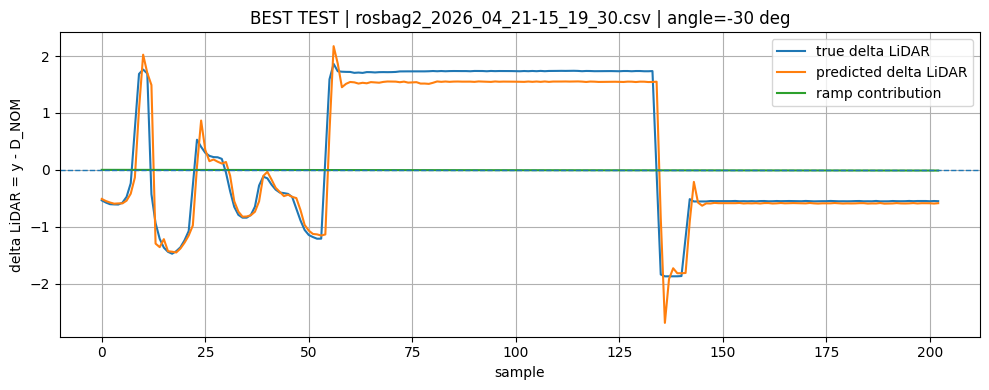

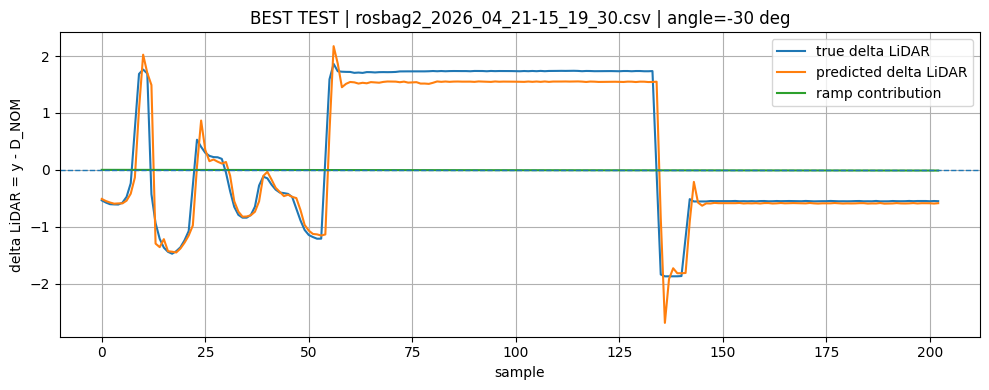

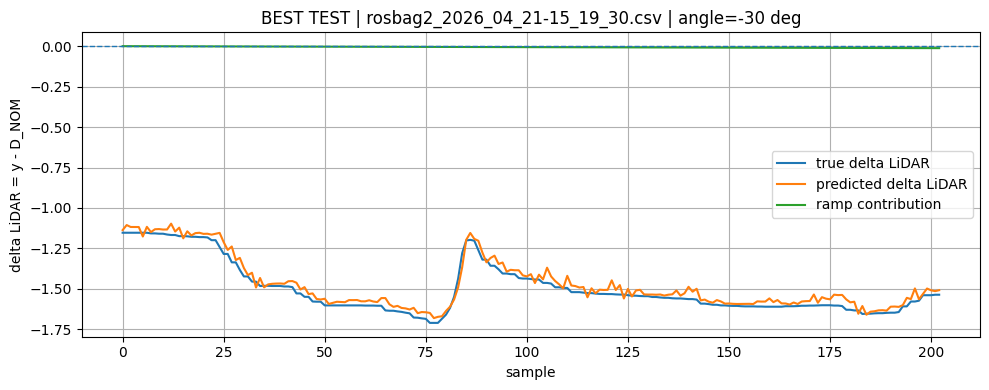

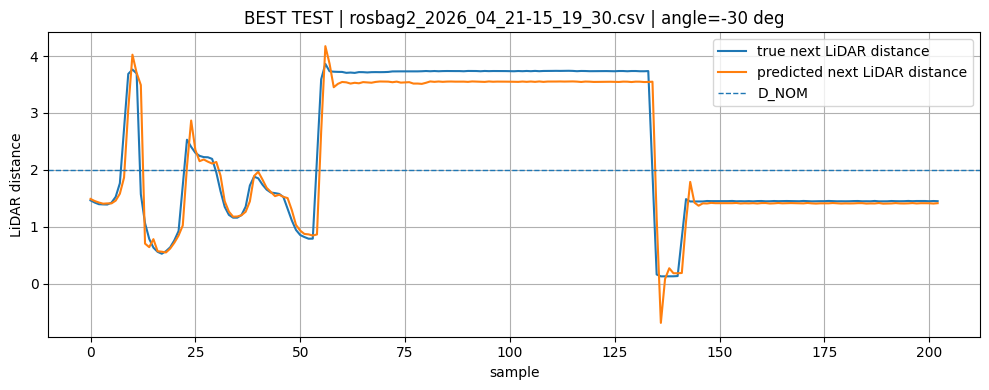

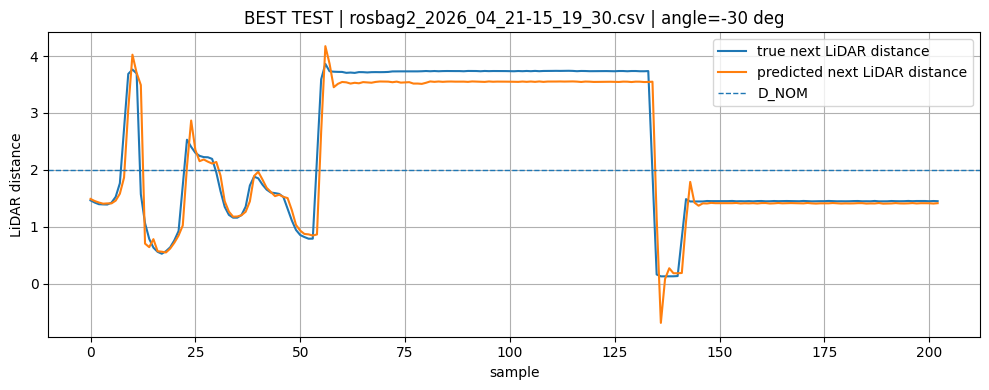

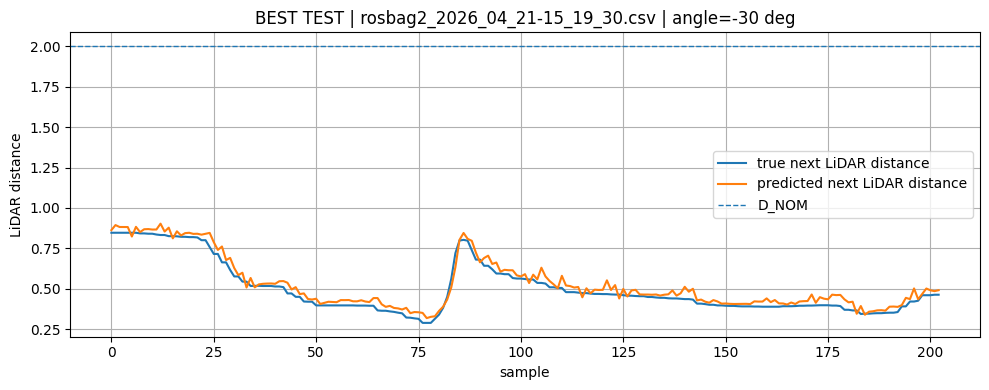

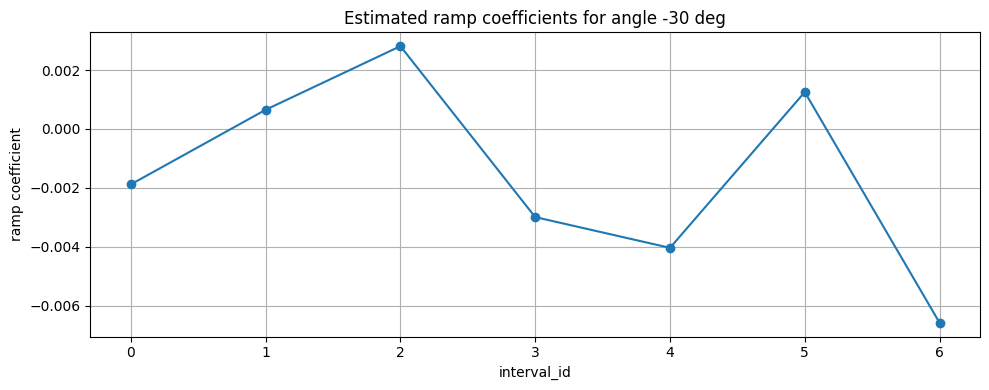

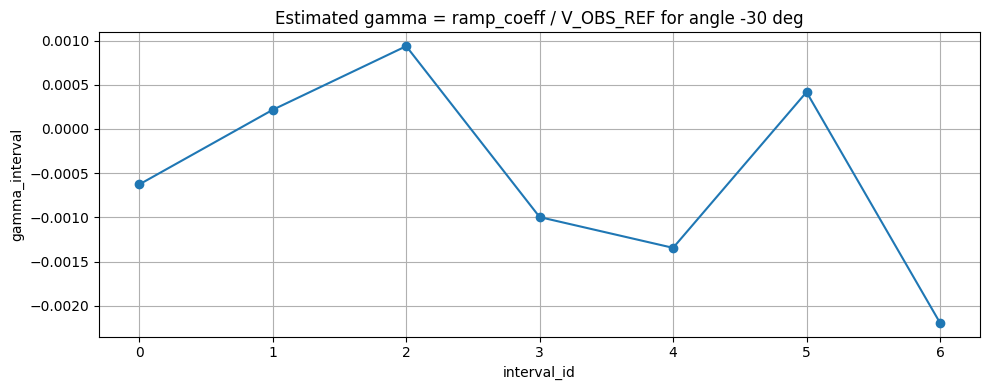

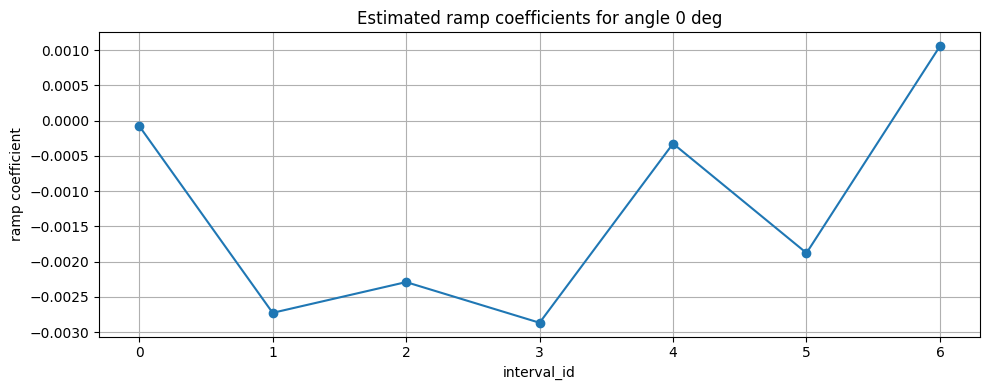

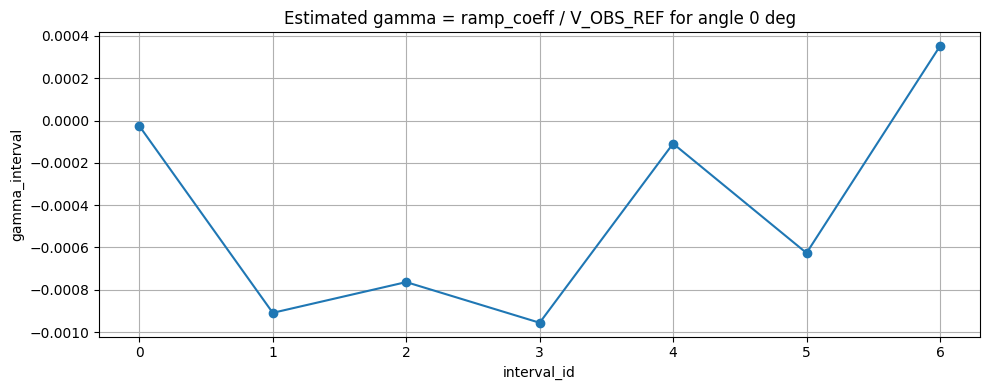

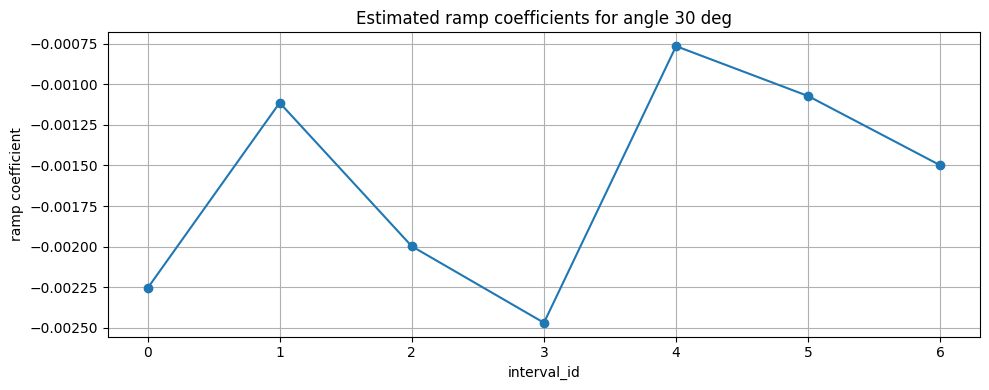

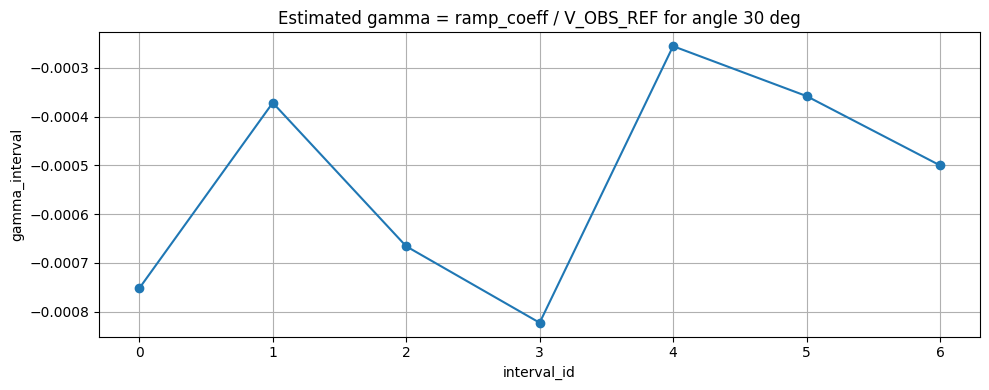

In [ ]:
# @title
best_idx = results_df["score"].idxmin()
best_summary = results_df.loc[best_idx]

print("\n=== Best configuration ===")
print(best_summary)

best_run = all_runs[int(best_idx)]

print("\n=== Best run: dynamic coefficients ===")
print(best_run["global_coeff_df"])

print("\n=== Best run: ramp coefficients ===")
print(best_run["ramp_coeff_df"])

plot_some_delta_predictions(
    best_run["test_preds"],
    max_plots=N_PLOTS_PER_SPLIT,
    title_prefix="BEST TEST"
)

plot_some_lidar_predictions(
    best_run["test_preds"],
    d_nom=D_NOM,
    max_plots=N_PLOTS_PER_SPLIT,
    title_prefix="BEST TEST"
)

plot_ramp_coefficients(best_run["ramp_coeff_df"])

In [ ]:
jsondata = {}
jsondata["config"] = {}
jsondata["config"]["na"] = NA
jsondata["config"]["nb"] = NB
jsondata["config"]["D_nom"] = results_df.loc[best_idx]["D_NOM"]
jsondata["config"]["V_nom"] = V_NOM
jsondata["config"]["delta_nom"] = DELTA_NOM
jsondata["config"]["angles"] = ANGLES_DEG
jsondata["config"]["interval_duration"] = results_df.loc[best_idx]["INTERVAL_DURATION"]
jsondata["config"]["Ts"] = TS
jsondata["models"] = {}

global_df = best_run["global_coeff_df"]
ramp_df = best_run["ramp_coeff_df"]

for angle in ANGLES_DEG:
    row = global_df[global_df["angle"] == angle].iloc[0]
    a_coeffs = list(row["a_coeffs"])
    b_v = list(row["b_v"])
    b_delta = list(row["b_delta"])
    ramps = list(ramp_df[ramp_df["angle"] == angle]["ramp_coeff"]) # Swap to "gamma_interval" if preferred

    jsondata["models"][str(angle)] = {
        "a_coeffs": a_coeffs,
        "b_v": b_v,
        "b_delta": b_delta,
        "theta": a_coeffs + b_v + b_delta + ramps
    }
jsondata_filename = os.path.join(DATA_FOLDER, "data_"+datetime.datetime.today().strftime('%Y_%m_%d__%H_%M_%S')+".json")
with open(jsondata_filename, "w") as f:
    json.dump(jsondata, f, indent=4)

In [ ]:
# @title
"""
no_obs_file = "/content/drive/MyDrive/Lidar_data/lidar_test.csv"
"""

'\nno_obs_file = "/content/drive/MyDrive/Lidar_data/lidar_test.csv"\n'

In [ ]:
# @title
"""
no_obs_data = build_split_dataset(
    dfs=[no_obs_file],
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB,
    speed_col=SPEED_COL,
    steer_col=STEER_COL,
    v_nom=V_NOM,
    delta_nom=DELTA_NOM,
    d_nom=best_run["summary"]["D_NOM"],
    interval_len=int(best_run["summary"]["INTERVAL_LEN"]),
    ts=TS,
    use_lidar_clip=USE_LIDAR_CLIP,
    lidar_min=LIDAR_MIN,
    lidar_max=LIDAR_MAX,
    include_ramps=True
)
"""

'\nno_obs_data = build_split_dataset(\n    dfs=[no_obs_file],\n    angles_deg=ANGLES_DEG,\n    na=NA,\n    nb=NB,\n    speed_col=SPEED_COL,\n    steer_col=STEER_COL,\n    v_nom=V_NOM,\n    delta_nom=DELTA_NOM,\n    d_nom=best_run["summary"]["D_NOM"],\n    interval_len=int(best_run["summary"]["INTERVAL_LEN"]),\n    ts=TS,\n    use_lidar_clip=USE_LIDAR_CLIP,\n    lidar_min=LIDAR_MIN,\n    lidar_max=LIDAR_MAX,\n    include_ramps=True\n)\n'

In [ ]:
# @title
"""
no_obs_preds = evaluate_split(
    split_data=no_obs_data,
    models=best_run["models"],
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB,
    d_nom=best_run["summary"]["D_NOM"]
)
"""

'\nno_obs_preds = evaluate_split(\n    split_data=no_obs_data,\n    models=best_run["models"],\n    angles_deg=ANGLES_DEG,\n    na=NA,\n    nb=NB,\n    d_nom=best_run["summary"]["D_NOM"]\n)\n'

In [ ]:
# @title
"""
no_obs_metrics = predictions_to_dataframe(no_obs_preds)
print(no_obs_metrics)
print("\nMean RMSE:", no_obs_metrics["rmse"].mean())
print("Mean R2:", no_obs_metrics["r2"].mean())
"""

'\nno_obs_metrics = predictions_to_dataframe(no_obs_preds)\nprint(no_obs_metrics)\nprint("\nMean RMSE:", no_obs_metrics["rmse"].mean())\nprint("Mean R2:", no_obs_metrics["r2"].mean())\n'

In [ ]:
# @title
"""
plot_some_delta_predictions(
    no_obs_preds,
    max_plots=10,
    title_prefix="NO MOVING OBSTACLES TEST"
)
"""

'\nplot_some_delta_predictions(\n    no_obs_preds,\n    max_plots=10,\n    title_prefix="NO MOVING OBSTACLES TEST"\n)\n'

In [ ]:
# @title
"""
plot_some_lidar_predictions(
    no_obs_preds,
    d_nom=D_NOM,
    max_plots=10,
    title_prefix="NO MOVING OBSTACLES TEST"
)
"""

'\nplot_some_lidar_predictions(\n    no_obs_preds,\n    d_nom=D_NOM,\n    max_plots=10,\n    title_prefix="NO MOVING OBSTACLES TEST"\n)\n'

In [ ]:
# @title
"""
no_obs_metrics.groupby("angle")[["rmse", "r2"]].mean()
"""

'\nno_obs_metrics.groupby("angle")[["rmse", "r2"]].mean()\n'

In [ ]:
# @title
"""
import json

def serialize_models(models, config):
    data = {
        "config": config,
        "models": {}
    }

    for ang, m in models.items():
        data["models"][str(ang)] = {
            "a_coeffs": m["a_coeffs"].tolist(),
            "b_v": m["b_v"].tolist(),
            "b_delta": m["b_delta"].tolist(),
            "theta": m["theta"].tolist()
        }

    return data
"""

'\nimport json\n\ndef serialize_models(models, config):\n    data = {\n        "config": config,\n        "models": {}\n    }\n\n    for ang, m in models.items():\n        data["models"][str(ang)] = {\n            "a_coeffs": m["a_coeffs"].tolist(),\n            "b_v": m["b_v"].tolist(),\n            "b_delta": m["b_delta"].tolist(),\n            "theta": m["theta"].tolist()\n        }\n\n    return data\n'

In [ ]:
# @title
"""
config = {
    "na": NA,
    "nb": NB,
    "D_nom": best_run["summary"]["D_NOM"],
    "V_nom": V_NOM,
    "delta_nom": DELTA_NOM,
    "angles": ANGLES_DEG,
    "interval_duration": best_run["summary"]["INTERVAL_DURATION"],
    "Ts": TS
}
"""

'\nconfig = {\n    "na": NA,\n    "nb": NB,\n    "D_nom": best_run["summary"]["D_NOM"],\n    "V_nom": V_NOM,\n    "delta_nom": DELTA_NOM,\n    "angles": ANGLES_DEG,\n    "interval_duration": best_run["summary"]["INTERVAL_DURATION"],\n    "Ts": TS\n}\n'

In [ ]:
# @title
"""
model_data = serialize_models(best_run["models"], config)
drive_path = "/content/drive/MyDrive/Lidar_data/arx_lidar_model.json"

with open(drive_path, "w") as f:
    json.dump(model_data, f, indent=4)
"""

'\nmodel_data = serialize_models(best_run["models"], config)\ndrive_path = "/content/drive/MyDrive/Lidar_data/arx_lidar_model.json"\n\nwith open(drive_path, "w") as f:\n    json.dump(model_data, f, indent=4)\n'

In [ ]:
# @title
"""
files = load_csv_files(DATA_FOLDER, FILE_PATTERN)
train_files, val_files, test_files = split_files(
    files,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO
)

print("Number of files:")
print("  train:", len(train_files))
print("  val  :", len(val_files))
print("  test :", len(test_files))
print()
print(f"TS = {TS} s")
print(f"INTERVAL_DURATION = {INTERVAL_DURATION} s")
print(f"INTERVAL_LEN = {INTERVAL_LEN} samples")

train_data = build_split_dataset(
    file_list=train_files,
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB,
    speed_col=SPEED_COL,
    steer_col=STEER_COL,
    v_nom=V_NOM,
    delta_nom=DELTA_NOM,
    d_nom=D_NOM,
    interval_len=INTERVAL_LEN,
    ts=TS,
    use_clip=USE_CLIP,
    intrusion_min=INTRUSION_MIN,
    intrusion_max=INTRUSION_MAX,
    include_ramps=True
)

val_data = build_split_dataset(
    file_list=val_files,
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB,
    speed_col=SPEED_COL,
    steer_col=STEER_COL,
    v_nom=V_NOM,
    delta_nom=DELTA_NOM,
    d_nom=D_NOM,
    interval_len=INTERVAL_LEN,
    ts=TS,
    use_clip=USE_CLIP,
    intrusion_min=INTRUSION_MIN,
    intrusion_max=INTRUSION_MAX,
    include_ramps=True
)

test_data = build_split_dataset(
    file_list=test_files,
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB,
    speed_col=SPEED_COL,
    steer_col=STEER_COL,
    v_nom=V_NOM,
    delta_nom=DELTA_NOM,
    d_nom=D_NOM,
    interval_len=INTERVAL_LEN,
    ts=TS,
    use_clip=USE_CLIP,
    intrusion_min=INTRUSION_MIN,
    intrusion_max=INTRUSION_MAX,
    include_ramps=True
)

models = fit_models_per_angle(
    train_data=train_data,
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB
)

global_coeff_df, ramp_coeff_df = summarize_model_coefficients(
    models=models,
    v_obs_ref=V_OBS_REF
)

print("\n=== Dynamic coefficients per angle ===")
print(global_coeff_df)

print("\n=== Ramp coefficients per interval ===")
print(ramp_coeff_df)

train_preds = evaluate_split(
    split_data=train_data,
    models=models,
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB,
    d_nom=D_NOM,
    use_clip=USE_CLIP,
    intrusion_min=INTRUSION_MIN,
    intrusion_max=INTRUSION_MAX
)

val_preds = evaluate_split(
    split_data=val_data,
    models=models,
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB,
    d_nom=D_NOM,
    use_clip=USE_CLIP,
    intrusion_min=INTRUSION_MIN,
    intrusion_max=INTRUSION_MAX
)

test_preds = evaluate_split(
    split_data=test_data,
    models=models,
    angles_deg=ANGLES_DEG,
    na=NA,
    nb=NB,
    d_nom=D_NOM,
    use_clip=USE_CLIP,
    intrusion_min=INTRUSION_MIN,
    intrusion_max=INTRUSION_MAX
)

train_metrics = predictions_to_dataframe(train_preds)
val_metrics = predictions_to_dataframe(val_preds)
test_metrics = predictions_to_dataframe(test_preds)

print("\n=== Train metrics ===")
print(train_metrics)

print("\n=== Validation metrics ===")
print(val_metrics)

print("\n=== Test metrics ===")
print(test_metrics)

if len(test_metrics) > 0:
    print("\n=== Mean test metrics by angle ===")
    print(test_metrics.groupby("angle")[["rmse", "r2"]].mean())

plot_some_intrusion_predictions(train_preds, max_plots=N_PLOTS_PER_SPLIT, title_prefix="TRAIN")
plot_some_lidar_predictions(train_preds, max_plots=N_PLOTS_PER_SPLIT, title_prefix="TRAIN")

plot_some_intrusion_predictions(val_preds, max_plots=N_PLOTS_PER_SPLIT, title_prefix="VAL")
plot_some_lidar_predictions(val_preds, max_plots=N_PLOTS_PER_SPLIT, title_prefix="VAL")

plot_some_intrusion_predictions(test_preds, max_plots=N_PLOTS_PER_SPLIT, title_prefix="TEST")
plot_some_lidar_predictions(test_preds, max_plots=N_PLOTS_PER_SPLIT, title_prefix="TEST")

plot_ramp_coefficients(ramp_coeff_df)
"""

'\nfiles = load_csv_files(DATA_FOLDER, FILE_PATTERN)\ntrain_files, val_files, test_files = split_files(\n    files,\n    train_ratio=TRAIN_RATIO,\n    val_ratio=VAL_RATIO,\n    test_ratio=TEST_RATIO\n)\n\nprint("Number of files:")\nprint("  train:", len(train_files))\nprint("  val  :", len(val_files))\nprint("  test :", len(test_files))\nprint()\nprint(f"TS = {TS} s")\nprint(f"INTERVAL_DURATION = {INTERVAL_DURATION} s")\nprint(f"INTERVAL_LEN = {INTERVAL_LEN} samples")\n\ntrain_data = build_split_dataset(\n    file_list=train_files,\n    angles_deg=ANGLES_DEG,\n    na=NA,\n    nb=NB,\n    speed_col=SPEED_COL,\n    steer_col=STEER_COL,\n    v_nom=V_NOM,\n    delta_nom=DELTA_NOM,\n    d_nom=D_NOM,\n    interval_len=INTERVAL_LEN,\n    ts=TS,\n    use_clip=USE_CLIP,\n    intrusion_min=INTRUSION_MIN,\n    intrusion_max=INTRUSION_MAX,\n    include_ramps=True\n)\n\nval_data = build_split_dataset(\n    file_list=val_files,\n    angles_deg=ANGLES_DEG,\n    na=NA,\n    nb=NB,\n    speed_col=SPEED